In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [80]:
# from google.colab import drive
# drive.mount('/content/drive')
# file_path = "/content/drive/MyDrive/datasets/Houseprice_ds.xlsx"
file_path = "data.xlsx"
df = pd.read_excel(file_path)
df = pd.DataFrame(df)
df.head()


,Property ID,Location,Size,Bedrooms,Bathrooms,Year Built,Condition,Type,Date Sold,Price
0,SI_000001,CityA,3974.0,2.0,2.0,2007.0,Good,Single Family,2020-11-02,324000.0
1,SI_000002,CityA,1660.0,2.0,3.0,1934.0,Good,Single Family,2022-10-23,795000.0
2,SI_000003,CityC,2094.0,2.0,2.0,1950.0,Good,Single Family,2020-11-30,385000.0
3,SI_000004,CityB,1930.0,2.0,3.0,1905.0,Good,Single Family,2021-12-09,651000.0
4,SI_000005,CityB,1895.0,5.0,2.0,1936.0,New,Single Family,2024-10-30,1878000.0


In [81]:
df.shape

(247172, 10)

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247172 entries, 0 to 247171
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Property ID  247172 non-null  object        
 1   Location     247172 non-null  object        
 2   Size         244701 non-null  float64       
 3   Bedrooms     238769 non-null  float64       
 4   Bathrooms    240499 non-null  float64       
 5   Year Built   234567 non-null  float64       
 6   Condition    236544 non-null  object        
 7   Type         247172 non-null  object        
 8   Date Sold    247172 non-null  datetime64[ns]
 9   Price        241735 non-null  float64       
dtypes: datetime64[ns](1), float64(5), object(4)
memory usage: 18.9+ MB


In [83]:
df.describe()

,Size,Bedrooms,Bathrooms,Year Built,Date Sold,Price
count,244701.000000,238769.000000,240499.000000,234567.000000,247172,2.417350e+05
mean,2402.547664,3.000457,2.002823,1961.429191,2022-07-02 05:00:11.127473664,4.660883e+05
min,800.000000,1.000000,1.000000,1900.000000,2020-01-01 00:00:00,2.600000e+04
25%,1603.000000,2.000000,1.000000,1931.000000,2021-04-02 00:00:00,3.000000e+05
50%,2404.000000,3.000000,2.000000,1961.000000,2022-07-03 00:00:00,4.170000e+05
75%,3203.000000,4.000000,3.000000,1992.000000,2023-10-02 00:00:00,5.770000e+05
max,3999.000000,5.000000,3.000000,2023.000000,2024-12-31 00:00:00,2.223000e+06
std,923.418566,1.415088,0.816616,35.752638,NaN,2.315026e+05


In [84]:
df.isnull().sum()



Property ID        0
Location           0
Size            2471
Bedrooms        8403
Bathrooms       6673
Year Built     12605
Condition      10628
Type               0
Date Sold          0
Price           5437
dtype: int64

In [85]:
df = df.drop_duplicates()

In [86]:
df = df = df.drop(columns=['Property ID'])

In [87]:
df = df.dropna(subset=['Price'])


In [88]:
df.isnull().sum()

Location         0
Size             0
Bedrooms      2966
Bathrooms     1236
Year Built    7168
Condition     5191
Type             0
Date Sold        0
Price            0
dtype: int64

In [89]:
df = df.dropna(subset=['Year Built'])

In [90]:
df.isnull().sum()


Location      0
Size          0
Bedrooms      0
Bathrooms     0
Year Built    0
Condition     0
Type          0
Date Sold     0
Price         0
dtype: int64

Replacing Year Built could have been done using median but this particular column highly contributes to the prediction and hence incorrect filling might result in decreased accuracy

In [91]:
df['Sale_Year'] = pd.to_datetime(df['Date Sold']).dt.year
df['Sale_Month'] = pd.to_datetime(df['Date Sold']).dt.month

In [92]:
df = df.drop(columns=['Date Sold'])


In [93]:
df.head()


,Location,Size,Bedrooms,Bathrooms,Year Built,Condition,Type,Price,Sale_Year,Sale_Month
0,CityA,3974.0,2.0,2.0,2007.0,Good,Single Family,324000.0,2020,11
1,CityA,1660.0,2.0,3.0,1934.0,Good,Single Family,795000.0,2022,10
2,CityC,2094.0,2.0,2.0,1950.0,Good,Single Family,385000.0,2020,11
3,CityB,1930.0,2.0,3.0,1905.0,Good,Single Family,651000.0,2021,12
4,CityB,1895.0,5.0,2.0,1936.0,New,Single Family,1878000.0,2024,10


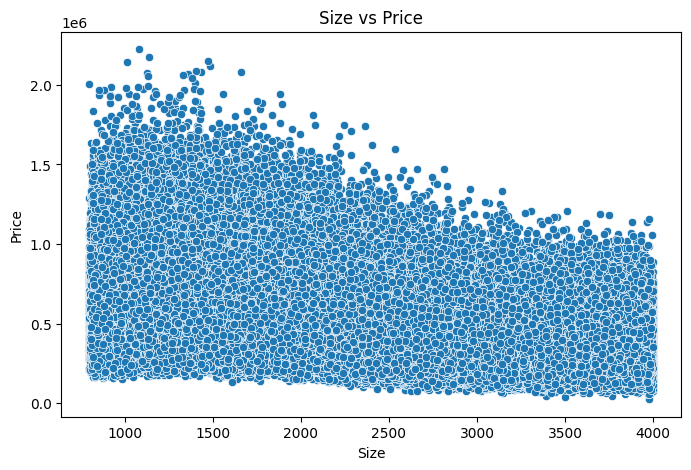

In [94]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Size', y='Price', data=df, alpha=1)
plt.title("Size vs Price")
plt.show()


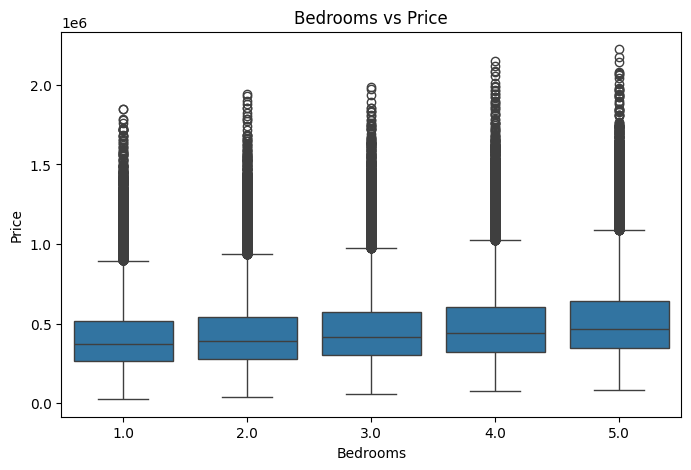

In [95]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Bedrooms', y='Price', data=df)
plt.title("Bedrooms vs Price")
plt.show()


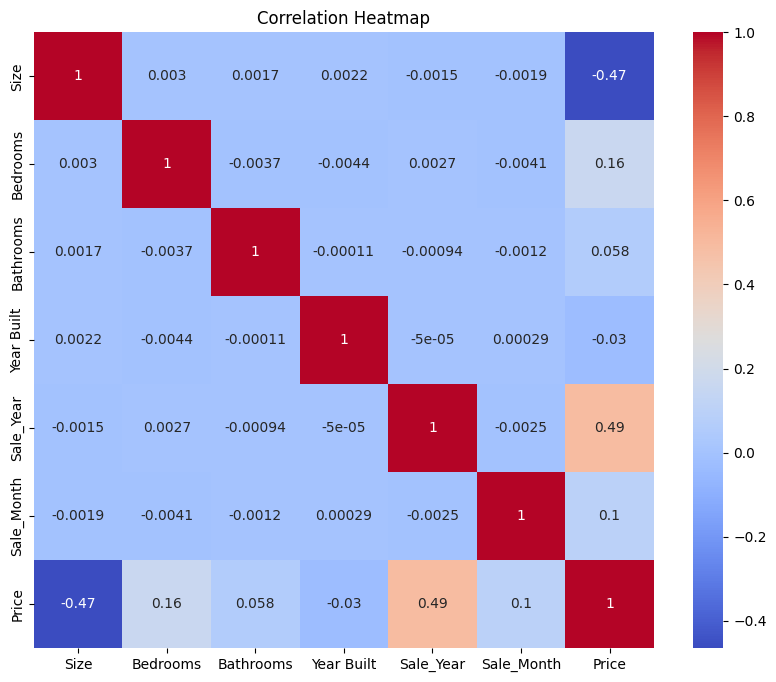

In [96]:
plt.figure(figsize=(10,8))
corr = df[['Size','Bedrooms','Bathrooms','Year Built','Sale_Year','Sale_Month','Price']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()



In [97]:
df['House Age'] = df['Sale_Year'] - df['Year Built']  


Now we know that size and prize is inversily proportional which is not true in rl. so we check if this inverse relationship is real or some random noices. by checking the trend in multiple devisions.

In [98]:
df['Size_bin'] = pd.cut(df['Size'], bins=5)
df.groupby('Size_bin')['Price'].mean()


C:\Users\Ashish\AppData\Local\Temp\ipykernel_12312\998406147.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Size_bin')['Price'].mean()


Size_bin
(796.801, 1439.8]    609267.443101
(1439.8, 2079.6]     571074.182957
(2079.6, 2719.4]     450950.644465
(2719.4, 3359.2]     368095.315708
(3359.2, 3999.0]     332573.854098
Name: Price, dtype: float64

Now we know that the inverse proportion is real in data.

In [99]:
df.groupby('Location')['Size'].corr(df['Price'])


Location
CityA   -0.561914
CityB   -0.455364
CityC   -0.507950
CityD   -0.539308
Name: Size, dtype: float64

This signifies that there's isn't even simpson's paradox. as in that correlaion is -ve globally and +ve for categories.


Encoding catergorical data.


In [100]:
df.dtypes
df.drop(columns=['Size_bin'], inplace=True)


In [101]:
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

categorical_cols = ['Location', 'Condition','Type']
numerical_cols = df.drop(columns=categorical_cols).columns

ohe = OrdinalEncoder()   
encoded_array = ohe.fit_transform(df[categorical_cols])

encoded_cols = categorical_cols

df_encoded = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index)
df_numerical = df[numerical_cols]

df_final = pd.concat([df_numerical, df_encoded], axis=1)


In [102]:
df_final.shape
df_final.head()


,Size,Bedrooms,Bathrooms,Year Built,Price,Sale_Year,Sale_Month,House Age,Location,Condition,Type
0,3974.0,2.0,2.0,2007.0,324000.0,2020,11,13.0,0.0,1.0,1.0
1,1660.0,2.0,3.0,1934.0,795000.0,2022,10,88.0,0.0,1.0,1.0
2,2094.0,2.0,2.0,1950.0,385000.0,2020,11,70.0,2.0,1.0,1.0
3,1930.0,2.0,3.0,1905.0,651000.0,2021,12,116.0,1.0,1.0,1.0
4,1895.0,5.0,2.0,1936.0,1878000.0,2024,10,88.0,1.0,2.0,1.0


Correlation after encoding.

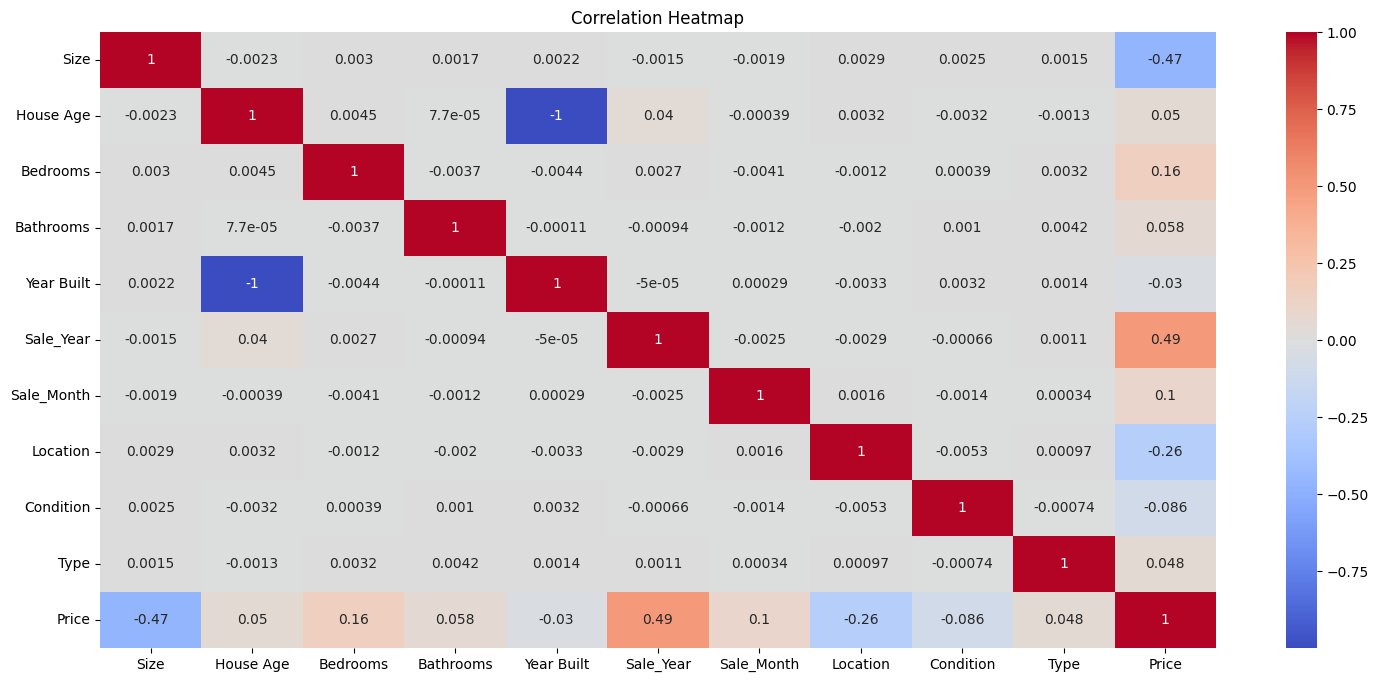

In [103]:
plt.figure(figsize=(18,8))
corr = df_final[['Size', 'House Age','Bedrooms','Bathrooms','Year Built', 'Sale_Year','Sale_Month','Location','Condition','Type','Price']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [104]:
df_final = df_final.drop(columns=['House Age'])
df_final = df_final.drop(columns=['Year Built'])
# df_final = df_final.drop(columns=['Sale_Month'])
df_final = df_final.drop(columns=['Bathrooms'])
# df_final = df_final.drop(columns=['Type'])
df_final.dtypes


Size          float64
Bedrooms      float64
Price         float64
Sale_Year       int32
Sale_Month      int32
Location      float64
Condition     float64
Type          float64
dtype: object

In [105]:
X = df_final.drop('Price', axis=1)
y = df_final['Price']


In [106]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.05,
    random_state=42
)


Linear Regession

In [107]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)


Linear Regression Performance:
MAE : 113515.8283068621
RMSE: 150962.30090711586
R2  : 0.5699369329852451


Decision Tree

In [108]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    max_depth=6,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Performance:")
print("MAE :", mae_dt)
print("RMSE:", rmse_dt)
print("R2  :", r2_dt)


Decision Tree Performance:
MAE : 72905.94614083576
RMSE: 101259.79780905946
R2  : 0.806505223082011


Random Forest

In [109]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)


Random Forest Performance:
MAE : 23543.789133094335
RMSE: 29898.73523786723
R2  : 0.9831305559783446


Gradient Boosting

In [110]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting Performance:")
print("MAE :", mae_gbr)
print("RMSE:", rmse_gbr)
print("R2  :", r2_gbr)


Gradient Boosting Performance:
MAE : 34583.01645866277
RMSE: 52792.208324254454
R2  : 0.9474061706424703


XG Boost

In [111]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance:")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2  :", r2_xgb)

XGBoost Performance:
MAE : 26981.552420815926
RMSE: 38901.90843580027
R2  : 0.971441397654559


LIGHTGBM

In [112]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train
lgbm_model.fit(X_train, y_train)

# Predict
y_train_pred = lgbm_model.predict(X_train)
y_test_pred = lgbm_model.predict(X_test)

# Metrics for LightGBM
r2_lgbm = r2_score(y_test, y_test_pred)
mae_lgbm = mean_absolute_error(y_test, y_test_pred)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2 :", r2_lgbm)
print("Test MAE:", mae_lgbm)
print("Test RMSE:", rmse_lgbm)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004410 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 291
[LightGBM] [Info] Number of data points in the train set: 222838, number of used features: 7
[LightGBM] [Info] Start training from score 465843.796839
Train R2: 0.9878925572580692
Test R2 : 0.9870989632612838
Test MAE: 20672.828196053117
Test RMSE: 26146.570843306996


K nearest Neighbours

In [113]:
from sklearn.preprocessing import RobustScaler
scaler1 = RobustScaler()

X_train_scaled = scaler1.fit_transform(X_train)
X_test_scaled = scaler1.transform(X_test)   

In [114]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

print("KNN -> MAE:", mae_knn)
print("KNN -> RMSE:", rmse_knn)
print("KNN -> R2:", r2_knn)


KNN -> MAE: 24377.559894279137
KNN -> RMSE: 31957.082440100552
KNN -> R2: 0.9807278849016634


Ridge

In [115]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge -> MAE:", mae_ridge)
print("Ridge -> RMSE:", rmse_ridge)
print("Ridge -> R2:", r2_ridge)


Ridge -> MAE: 113515.62158325345
Ridge -> RMSE: 150962.2861514545
Ridge -> R2: 0.5699370170574225


Lasso

In [116]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso -> MAE:", mae_lasso)
print("Lasso -> RMSE:", rmse_lasso)
print("Lasso -> R2:", r2_lasso)


Lasso -> MAE: 113515.82558074153
Lasso -> RMSE: 150962.30104211267
Lasso -> R2: 0.5699369322160843


Elastic Net

In [117]:
from sklearn.linear_model import ElasticNet
elastic = ElasticNet(alpha=0.01, l1_ratio=0.5)
elastic.fit(X_train_scaled, y_train)

y_pred_elastic = elastic.predict(X_test_scaled)

mae_elastic = mean_absolute_error(y_test, y_pred_elastic)
rmse_elastic = np.sqrt(mean_squared_error(y_test, y_pred_elastic))
r2_elastic = r2_score(y_test, y_pred_elastic)

print("ElasticNet -> MAE:", mae_elastic)
print("ElasticNet -> RMSE:", rmse_elastic)
print("ElasticNet -> R2:", r2_elastic)


ElasticNet -> MAE: 113311.44003970666
ElasticNet -> RMSE: 150973.78031177475
ElasticNet -> R2: 0.5698715251894053


Comparision:


In [118]:
results = {
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "LightGBM",
        "KNN",
        "Ridge",
        "Lasso",
        "ElasticNet"
    ],
    "MAE": [
        mae,
        mae_dt,
        mae_rf,
        mae_gbr,
        mae_xgb,
        mae_lgbm,
        mae_knn,
        mae_ridge,
        mae_lasso,
        mae_elastic
    ],
    "RMSE": [
        rmse,
        rmse_dt,
        rmse_rf,
        rmse_gbr,
        rmse_xgb,
        rmse_lgbm,
        rmse_knn,
        rmse_ridge,
        rmse_lasso,
        rmse_elastic
    ],
    "R2 Score": [
        r2,
        r2_dt,
        r2_rf,
        r2_gbr,
        r2_xgb,
        r2_lgbm,
        r2_knn,
        r2_ridge,
        r2_lasso,
        r2_elastic
    ]
}

comparison_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)

comparison_df


,Model,MAE,RMSE,R2 Score
5,LightGBM,20672.828196,26146.570843,0.987099
2,Random Forest,23543.789133,29898.735238,0.983131
6,KNN,24377.559894,31957.082440,0.980728
4,XGBoost,26981.552421,38901.908436,0.971441
3,Gradient Boosting,34583.016459,52792.208324,0.947406
1,Decision Tree,72905.946141,101259.797809,0.806505
7,Ridge,113515.621583,150962.286151,0.569937
0,Linear Regression,113515.828307,150962.300907,0.569937
8,Lasso,113515.825581,150962.301042,0.569937
9,ElasticNet,113311.440040,150973.780312,0.569872


hYperparater tuning.

LightGBM

In [119]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [500, 800, 1000, 1500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'num_leaves': [15, 31, 50, 70],
    'max_depth': [-1, 5, 10, 15],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

lgbm = LGBMRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_grid,
    n_iter=20,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Hyperparameters:", random_search.best_params_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005560 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 291
[LightGBM] [Info] Number of data points in the train set: 222838, number of used features: 7
[LightGBM] [Info] Start training from score 465843.796839
Best Hyperparameters: {'subsample': 0.6, 'num_leaves': 50, 'n_estimators': 1500, 'max_depth': 10, 'learning_rate': 0.03, 'colsample_bytree': 0.6}


In [120]:
from lightgbm import LGBMRegressor

# Rebuild model from scratch using best hyperparameters
best_lgbm_model = LGBMRegressor(
    subsample=0.6,
    num_leaves=50,
    n_estimators=1500,
    max_depth=10,
    learning_rate=0.03,
    colsample_bytree=0.6,
    random_state=42,
    n_jobs=-1
)

# Fit cleanly on training data
best_lgbm_model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_metric="rmse",
    
)

# Predict again
y_train_pred_tuned = best_lgbm_model.predict(X_train)
y_test_pred_tuned = best_lgbm_model.predict(X_test)

# Metrics after tuning
r2_lgbm_tuned = r2_score(y_test, y_test_pred_tuned)
mae_lgbm_tuned = mean_absolute_error(y_test, y_test_pred_tuned)
rmse_lgbm_tuned = np.sqrt(mean_squared_error(y_test, y_test_pred_tuned))

print("\nAfter Tuning (LightGBM)")
print("Train R2:", r2_score(y_train, y_train_pred_tuned))
print("Test R2 :", r2_lgbm_tuned)
print("Test MAE:", mae_lgbm_tuned)
print("Test RMSE:", rmse_lgbm_tuned)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004187 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 291
[LightGBM] [Info] Number of data points in the train set: 222838, number of used features: 7
[LightGBM] [Info] Start training from score 465843.796839

After Tuning (LightGBM)
Train R2: 0.9879781630647869
Test R2 : 0.987233612615143
Test MAE: 20589.088891023843
Test RMSE: 26009.765815383314


In [121]:
comparison_lgbm = pd.DataFrame({
    "Stage": ["Before Tuning", "After Tuning"],
    "R2 Score": [r2_lgbm, r2_lgbm_tuned],
    "MAE": [mae_lgbm, mae_lgbm_tuned],
    "RMSE": [rmse_lgbm, rmse_lgbm_tuned]
})

comparison_lgbm


,Stage,R2 Score,MAE,RMSE
0,Before Tuning,0.987099,20672.828196,26146.570843
1,After Tuning,0.987234,20589.088891,26009.765815


Checking for overfitting

In [122]:
y_train_pred = best_lgbm_model.predict(X_train)
y_test_pred  = best_lgbm_model.predict(X_test)

# R2 Scores
r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

print(f"Train R2 : {r2_train:.4f}")
print(f"Test  R2 : {r2_test:.4f}")


Train R2 : 0.9880
Test  R2 : 0.9872


now we can see that R2 value has no huge different for training and testing dataset, so there's no overfiting.

In [123]:
import pickle

with open('best_lgbm_model.pkl', 'wb') as f:
    pickle.dump(best_lgbm_model, f)

with open('ordinal_encoder.pkl', 'wb') as f:
    pickle.dump(ohe, f)

